In [1]:
#!pip install statsmodels

# 1. Environment Setup & Data Loading

## 1.1 Project configuration and global settings

In [2]:
import math
from pathlib import Path
from typing import Dict, List, Tuple
from itertools import combinations, product

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy.stats import chi2_contingency, kruskal

In [3]:
def setup_data():
    org_path = "../"
    raw_path = f"{org_path}data/raw/"
    prc_path = f"{org_path}data/processed/"
    eda_path = f"{org_path}outputs/eda/"
    seed = 42

    print("변수 세팅 완료")
    return org_path, raw_path, prc_path, eda_path, seed

# 사용 예시 (반환값 9개)
org_path, raw_path, prc_path, eda_path, seed = setup_data()

변수 세팅 완료


In [4]:
def set_display_options():
    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_rows', None)
    pd.set_option('display.float_format', lambda x: '%.3f' % x)
    print("디스플레이 옵션 설정 완료")
set_display_options()

디스플레이 옵션 설정 완료


## 1.2 Loading raw source files (CSV)

In [ ]:
def load_multiple_csv_with_schema(
    base_path: str,
    filenames: List[str],
) -> Tuple[Dict[str, pd.DataFrame], List[str], List[str], List[str], List[str], List[str]]:
    """
    여러 CSV 파일을 한 번에 불러오되,
    사전에 정의한 key/cat/int/float/target 타입에 따라 dtype을 지정하여 로딩.

    Returns
    -------
    dataframes : dict[str, pd.DataFrame]
        각 파일명을 key, DataFrame을 value로 하는 딕셔너리
    key_cols : list[str]
    target_cols : list[str]
    cat_cols : list[str]
    int_cols : list[str]
    float_cols : list[str]
    """

    # 1) 변수 그룹 정의
    key_cols = [
        "user_id",
        "session_id",
    ]

    target_cols = [
        "label_repurchase",
    ]

    cat_cols = [
        "session_main_events",
        "session_browser",
        "session_traffic_source",
        "session_state",

        # 시간 start
        "session_start_hour",
        "session_start_weekday",
        "session_start_is_weekend",
        "session_start_day",
        "session_start_week",
        "session_start_month",
        "session_start_quarter",
        "session_start_year",

        # 시간 end
        "session_end_hour",
        "session_end_weekday",
        "session_end_is_weekend",
        "session_end_day",
        "session_end_week",
        "session_end_month",
        "session_end_quarter",
        "session_end_year",

        # 상품 / 사용자
        "product_category",
        "user_gender",
        "user_country",
    ]

    int_cols = [
        "session_event_count",
        "event_type_nunique",
        "user_age",
    ]

    float_cols = [
        "session_duration_hour",
        "total_price",
    ]

    num_cols = int_cols + float_cols

    # 2) dtype 매핑
    dtype_map: dict = {}
    dtype_map.update({col: "string" for col in key_cols})
    dtype_map.update({col: "string" for col in cat_cols})  # 나중에 category 변환
    dtype_map.update({col: "Int64" for col in int_cols + target_cols})
    dtype_map.update({col: "float" for col in float_cols})
    

    # 3) 여러 CSV 로딩
    base = Path(base_path)
    dataframes: Dict[str, pd.DataFrame] = {}

    for name in filenames:
        file_path = base / f"{name}.csv"

        if not file_path.exists():
            print(f"파일 없음: {file_path}")
            continue

        df = pd.read_csv(file_path, dtype=dtype_map)
        dataframes[name] = df
        print(f"{name}.csv 로드 완료 — shape={df.shape}")

    return dataframes, key_cols, target_cols, cat_cols, int_cols, float_cols, num_cols

In [ ]:
file_list = [
    "train_df", "test_df"
]

# CSV 로드
dfs, key_cols, target_col, cat_cols, int_cols, float_cols, num_cols = load_multiple_csv_with_schema(
    base_path=prc_path,
    filenames=file_list
)

train_df.csv 로드 완료 — shape=(62509, 31)
test_df.csv 로드 완료 — shape=(15628, 31)


In [7]:
# 변수 자동 생성
for name, df in dfs.items():
    globals()[name] = df
    print(f"테이블 생성 완료: {name} (shape={df.shape})")
del dfs

테이블 생성 완료: train_df (shape=(62509, 31))
테이블 생성 완료: test_df (shape=(15628, 31))


# 2. 데이터 확인

데이터 분포

In [8]:
print("====train set====")
vc = train_df[target_col].value_counts()
out = pd.DataFrame({
    "count": vc.apply(lambda x: f"{x:,}"),
    "ratio": (vc / vc.sum()).round(3)
})
print(f"Total: {train_df.shape[0]:,}\n")
print(out)

print("====test set====")
vc = test_df[target_col].value_counts()
out = pd.DataFrame({
    "count": vc.apply(lambda x: f"{x:,}"),
    "ratio": (vc / vc.sum()).round(3)
})

print(f"Total: {test_df.shape[0]:,}\n")
print(out)

====train set====
Total: 62,509

                   count  ratio
label_repurchase               
1                 35,162  0.563
0                 27,347  0.437
====test set====
Total: 15,628

                  count  ratio
label_repurchase              
1                 8,791  0.563
0                 6,837  0.437


데이터 타입

In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62509 entries, 0 to 62508
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   62509 non-null  string 
 1   session_id                62509 non-null  string 
 2   session_event_count       62509 non-null  Int64  
 3   event_type_nunique        62509 non-null  Int64  
 4   session_main_events       62509 non-null  string 
 5   session_browser           62509 non-null  string 
 6   session_traffic_source    62509 non-null  string 
 7   session_state             62509 non-null  string 
 8   session_duration_hour     62509 non-null  float64
 9   session_start_hour        62509 non-null  string 
 10  session_start_weekday     62509 non-null  string 
 11  session_start_is_weekend  62509 non-null  string 
 12  session_start_day         62509 non-null  string 
 13  session_start_week        62509 non-null  string 
 14  sessio

In [10]:
train_df.describe(include='all')

,user_id,session_id,session_event_count,event_type_nunique,session_main_events,session_browser,session_traffic_source,session_state,session_duration_hour,session_start_hour,session_start_weekday,session_start_is_weekend,session_start_day,session_start_week,session_start_month,session_start_quarter,session_start_year,session_end_hour,session_end_weekday,session_end_is_weekend,session_end_day,session_end_week,session_end_month,session_end_quarter,session_end_year,label_repurchase,product_category,total_price,user_age,user_gender,user_country
count,62509,62509,62509.000,62509.000,62509,62509,62509,62509,62509.000,62509,62509,62509,62509,62509,62509,62509,62509,62509,62509,62509,62509,62509,62509,62509,62509,62509.000,62509,62509.000,62509.000,62509,62509
unique,62509,62509,<NA>,<NA>,5,5,5,228,NaN,23,7,2,31,53,12,4,6,24,7,2,31,53,12,4,6,<NA>,26,NaN,<NA>,2,15
top,88600,21284d47-513e-4c33-b98e-0c1b78a0810b,<NA>,<NA>,cart,Chrome,Email,Guangdong,NaN,10,0,0,14,2,12,4,2023,10,3,0,5,2,12,4,2023,<NA>,Intimates,NaN,<NA>,F,China
freq,1,1,<NA>,<NA>,15340,31351,28137,3356,NaN,3413,9133,44597,2221,1942,6941,19179,26607,3396,9045,44659,2201,1918,6914,19156,26563,<NA>,4665,NaN,<NA>,31365,21371
mean,NaN,NaN,6.058,4.700,NaN,NaN,NaN,NaN,14.534,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.563,NaN,86.097,41.036,NaN,NaN
std,NaN,NaN,2.052,0.458,NaN,NaN,NaN,NaN,28.743,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.496,NaN,118.358,17.024,NaN,NaN
min,NaN,NaN,5.000,4.000,NaN,NaN,NaN,NaN,0.007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,0.040,12.000,NaN,NaN
25%,NaN,NaN,5.000,4.000,NaN,NaN,NaN,NaN,0.089,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,27.950,26.000,NaN,NaN
50%,NaN,NaN,5.000,5.000,NaN,NaN,NaN,NaN,0.116,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,NaN,50.000,41.000,NaN,NaN
75%,NaN,NaN,7.000,5.000,NaN,NaN,NaN,NaN,0.269,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,NaN,99.880,56.000,NaN,NaN


In [11]:
train_df.head()

,user_id,session_id,session_event_count,event_type_nunique,session_main_events,session_browser,session_traffic_source,session_state,session_duration_hour,session_start_hour,session_start_weekday,session_start_is_weekend,session_start_day,session_start_week,session_start_month,session_start_quarter,session_start_year,session_end_hour,session_end_weekday,session_end_is_weekend,session_end_day,session_end_week,session_end_month,session_end_quarter,session_end_year,label_repurchase,product_category,total_price,user_age,user_gender,user_country
0,59678,deff0bf7-f8e6-4a1d-89a7-b388dcd8b743,5,5,purchase,Firefox,Adwords,Beijing,0.106,11,4,0,9,23,6,2,2023,11,4,0,9,23,6,2,2023,1,Accessories,50.000,63,M,China
1,77903,551b5d92-2a65-459b-a9ae-86ec20586e62,13,4,product,Firefox,Adwords,Nebraska,24.305,23,3,0,16,11,3,1,2023,0,5,1,18,11,3,1,2023,1,Plus,60.000,67,F,United States
2,64328,a788c59a-59ac-4ccd-9a72-c40ffa024284,5,5,purchase,Firefox,Facebook,Amazonas,0.099,16,2,0,18,42,10,4,2023,16,2,0,18,42,10,4,2023,0,Fashion Hoodies & Sweatshirts,47.180,21,M,Brasil
3,11476,18ea7d19-576e-49a4-b099-6c0732c45538,7,4,cart,Chrome,YouTube,Seoul,0.129,2,3,0,2,9,3,1,2023,3,3,0,2,9,3,1,2023,1,Outerwear & Coats,237.500,47,F,South Korea
4,35411,3a63d626-889c-4b0e-963f-d7465f377d1f,5,5,product,Safari,Email,Distrito Federal,0.075,7,0,0,8,2,1,1,2024,7,0,0,8,2,1,1,2024,1,Accessories,34.750,30,M,Brasil


변수별 특성 파악

In [12]:
import pandas as pd

def profile_column(df: pd.DataFrame, col: str, top_k: int = 5) -> dict:
    s = df[col]
    result = {}

    # -------------------------
    # 기본 통계
    # -------------------------
    unique_count = s.nunique(dropna=True)
    null_count = s.isna().sum()
    null_ratio = s.isna().mean()

    result["unique_count"] = int(unique_count)
    result["null_count"] = int(null_count)
    result["null_ratio"] = round(float(null_ratio), 2)   # 소수점 2자리

    # -------------------------
    # 수치형 변수 처리
    # -------------------------
    if pd.api.types.is_numeric_dtype(s):
        desc = s.describe()

        # min/max도 python float로 변환 + 소수점 2자리
        result["value_range"] = (
            round(float(desc["min"]), 2),
            round(float(desc["max"]), 2),
        )

        result["numeric_summary"] = {
            "mean":   round(float(desc["mean"]),   2),
            "std":    round(float(desc["std"]),    2),
            "q1":     round(float(desc["25%"]),    2),
            "median": round(float(desc["50%"]),    2),
            "q3":     round(float(desc["75%"]),    2),
            "max":    round(float(desc["max"]),    2),
        }

        result["top_categories"] = None

    # -------------------------
    # 범주형 변수 처리
    # -------------------------
    else:
        result["value_range"] = None
        result["numeric_summary"] = None

        # 고유값이 너무 많으면 top_categories 출력하지 않음
        if unique_count > 50:
            result["top_categories"] = None
        else:
            vc = s.value_counts(dropna=True).head(top_k)

            if len(vc) == 0:
                result["top_categories"] = None
            else:
                total = len(s) - null_count
                result["top_categories"] = {
                    str(idx): round(float(cnt / total), 2)   # 비율도 소수점 2자리
                    for idx, cnt in vc.items()
                }

    return result

In [13]:
def profile_dataframe(df: pd.DataFrame, top_k: int = 5) -> pd.DataFrame:
    records = []

    for col in df.columns:
        p = profile_column(df, col, top_k=top_k)
        p["column"] = col
        records.append(p)

    result_df = pd.DataFrame(records)

    # column이 첫 번째
    cols = ["column"] + [c for c in result_df.columns if c != "column"]
    return result_df[cols]

In [ ]:
profiles = profile_dataframe(train_df, top_k=10)
profiles.to_csv(f"{eda_path}train_df_profile.csv", index=False)
print("프로파일링 완료")
profiles

프로파일링 완료


,column,unique_count,null_count,null_ratio,value_range,numeric_summary,top_categories
0,user_id,62509,0,0.000,None,None,None
1,session_id,62509,0,0.000,None,None,None
2,session_event_count,4,0,0.000,"(5.0, 13.0)","{'mean': 6.06, 'std': 2.05, 'q1': 5.0, 'median...",None
3,event_type_nunique,2,0,0.000,"(4.0, 5.0)","{'mean': 4.7, 'std': 0.46, 'q1': 4.0, 'median'...",None
4,session_main_events,5,0,0.000,None,None,"{'cart': 0.25, 'product': 0.24, 'department': ..."


In [17]:
profiles

,column,unique_count,null_count,null_ratio,value_range,numeric_summary,top_categories
0,user_id,62509,0,0.000,None,None,None
1,session_id,62509,0,0.000,None,None,None
2,session_event_count,4,0,0.000,"(5.0, 13.0)","{'mean': 6.06, 'std': 2.05, 'q1': 5.0, 'median...",None
3,event_type_nunique,2,0,0.000,"(4.0, 5.0)","{'mean': 4.7, 'std': 0.46, 'q1': 4.0, 'median'...",None
4,session_main_events,5,0,0.000,None,None,"{'cart': 0.25, 'product': 0.24, 'department': ..."
5,session_browser,5,0,0.000,None,None,"{'Chrome': 0.5, 'Firefox': 0.2, 'Safari': 0.2,..."
6,session_traffic_source,5,0,0.000,None,None,"{'Email': 0.45, 'Adwords': 0.3, 'Facebook': 0...."
7,session_state,228,0,0.000,None,None,None
8,session_duration_hour,5222,0,0.000,"(0.01, 96.45)","{'mean': 14.53, 'std': 28.74, 'q1': 0.09, 'med...",None
9,session_start_hour,23,0,0.000,None,None,"{'10': 0.05, '12': 0.05, '3': 0.05, '1': 0.05,..."


## 시각화

범주형 

In [15]:
def plot_categorical_overview(
    df,
    cols,
    per_row=3,
    rotate=45,
    per_ax_size=(5, 3.5),
    na_label="NA",
    top_k=60,          # 기본 top_k
    topk_map=None,     # 특정 컬럼만 다른 top_k
    exclude_cols=None  # ⭐ 특정 컬럼 제외
):
    # ------------------------------
    # 0) 제외 컬럼 처리
    # ------------------------------
    exclude_cols = exclude_cols or []
    cols = [c for c in cols if c not in exclude_cols]

    n = len(cols)
    if n == 0:
        print("No categorical columns to plot after excluding.")
        return

    # ------------------------------
    # 1) subplot 설정
    # ------------------------------
    nrows = math.ceil(n / per_row)
    figsize = (per_ax_size[0] * per_row, per_ax_size[1] * nrows)
    fig, axes = plt.subplots(nrows, per_row, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    topk_map = topk_map or {}

    # ------------------------------
    # 2) 컬럼별 시각화
    # ------------------------------
    for i, col in enumerate(cols):
        ax = axes[i]

        # 결측 치환
        s = df[col].fillna(na_label)

        # 빈도 집계
        vc = s.value_counts(dropna=False)
        if vc.empty:
            ax.set_title(f"{col}\n(모든 값 결측)")
            ax.axis("off")
            continue

        # 값 기준 정렬
        vc = vc.sort_index()

        # 개별 top_k 적용 여부
        k = topk_map.get(col, top_k)
        if k is not None:
            vc = vc.head(k)

        counts = vc.values
        labels = vc.index.astype(str)
        x = np.arange(len(vc))

        # 막대그래프
        ax.bar(x, counts)

        # 평균선
        mean_cnt = counts.mean()
        ax.axhline(mean_cnt, linestyle="--", linewidth=1,
                   label=f"mean={mean_cnt:.0f}")

        # x축 설정
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=rotate)

        # 통계 정보
        uniq = df[col].nunique(dropna=False)
        uniq_fmt = f"{uniq:,}"

        total = vc.sum()
        top1_share = vc.iloc[0] / total if total > 0 else 0
        top5_share = vc.head(5).sum() / total if total > 0 else 0

        ax.set_title(col, fontsize=10)
        ax.set_ylabel("Count")
        ax.legend(fontsize=8, loc="upper right")

        # 각주
        ax.text(
            1.02, 0.5,
            f"uniq={uniq_fmt}\ntop1={top1_share:.1%}\ntop5={top5_share:.1%}",
            transform=ax.transAxes,
            va="center",
            fontsize=8
        )

    # 남은 subplot 삭제
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.show()

In [ ]:
# state, week 관련 변수의 경우 유니크 값이 개 이상 → 차원 수가 매우 많음
profiles[profiles['column'].isin(cat_cols)]

,column,unique_count,null_count,null_ratio,value_range,numeric_summary,top_categories
4,session_main_events,5,0,0.000,None,None,"{'cart': 0.25, 'product': 0.24, 'department': ..."
5,session_browser,5,0,0.000,None,None,"{'Chrome': 0.5, 'Firefox': 0.2, 'Safari': 0.2,..."
6,session_traffic_source,5,0,0.000,None,None,"{'Email': 0.45, 'Adwords': 0.3, 'Facebook': 0...."
7,session_state,228,0,0.000,None,None,None
9,session_start_hour,23,0,0.000,None,None,"{'10': 0.05, '12': 0.05, '3': 0.05, '1': 0.05,..."
10,session_start_weekday,7,0,0.000,None,None,"{'0': 0.15, '6': 0.15, '3': 0.14, '2': 0.14, '..."
11,session_start_is_weekend,2,0,0.000,None,None,"{'0': 0.71, '1': 0.29}"
12,session_start_day,31,0,0.000,None,None,"{'14': 0.04, '4': 0.04, '13': 0.03, '6': 0.03,..."
13,session_start_week,53,0,0.000,None,None,None
14,session_start_month,12,0,0.000,None,None,"{'12': 0.11, '11': 0.1, '1': 0.1, '10': 0.1, '..."


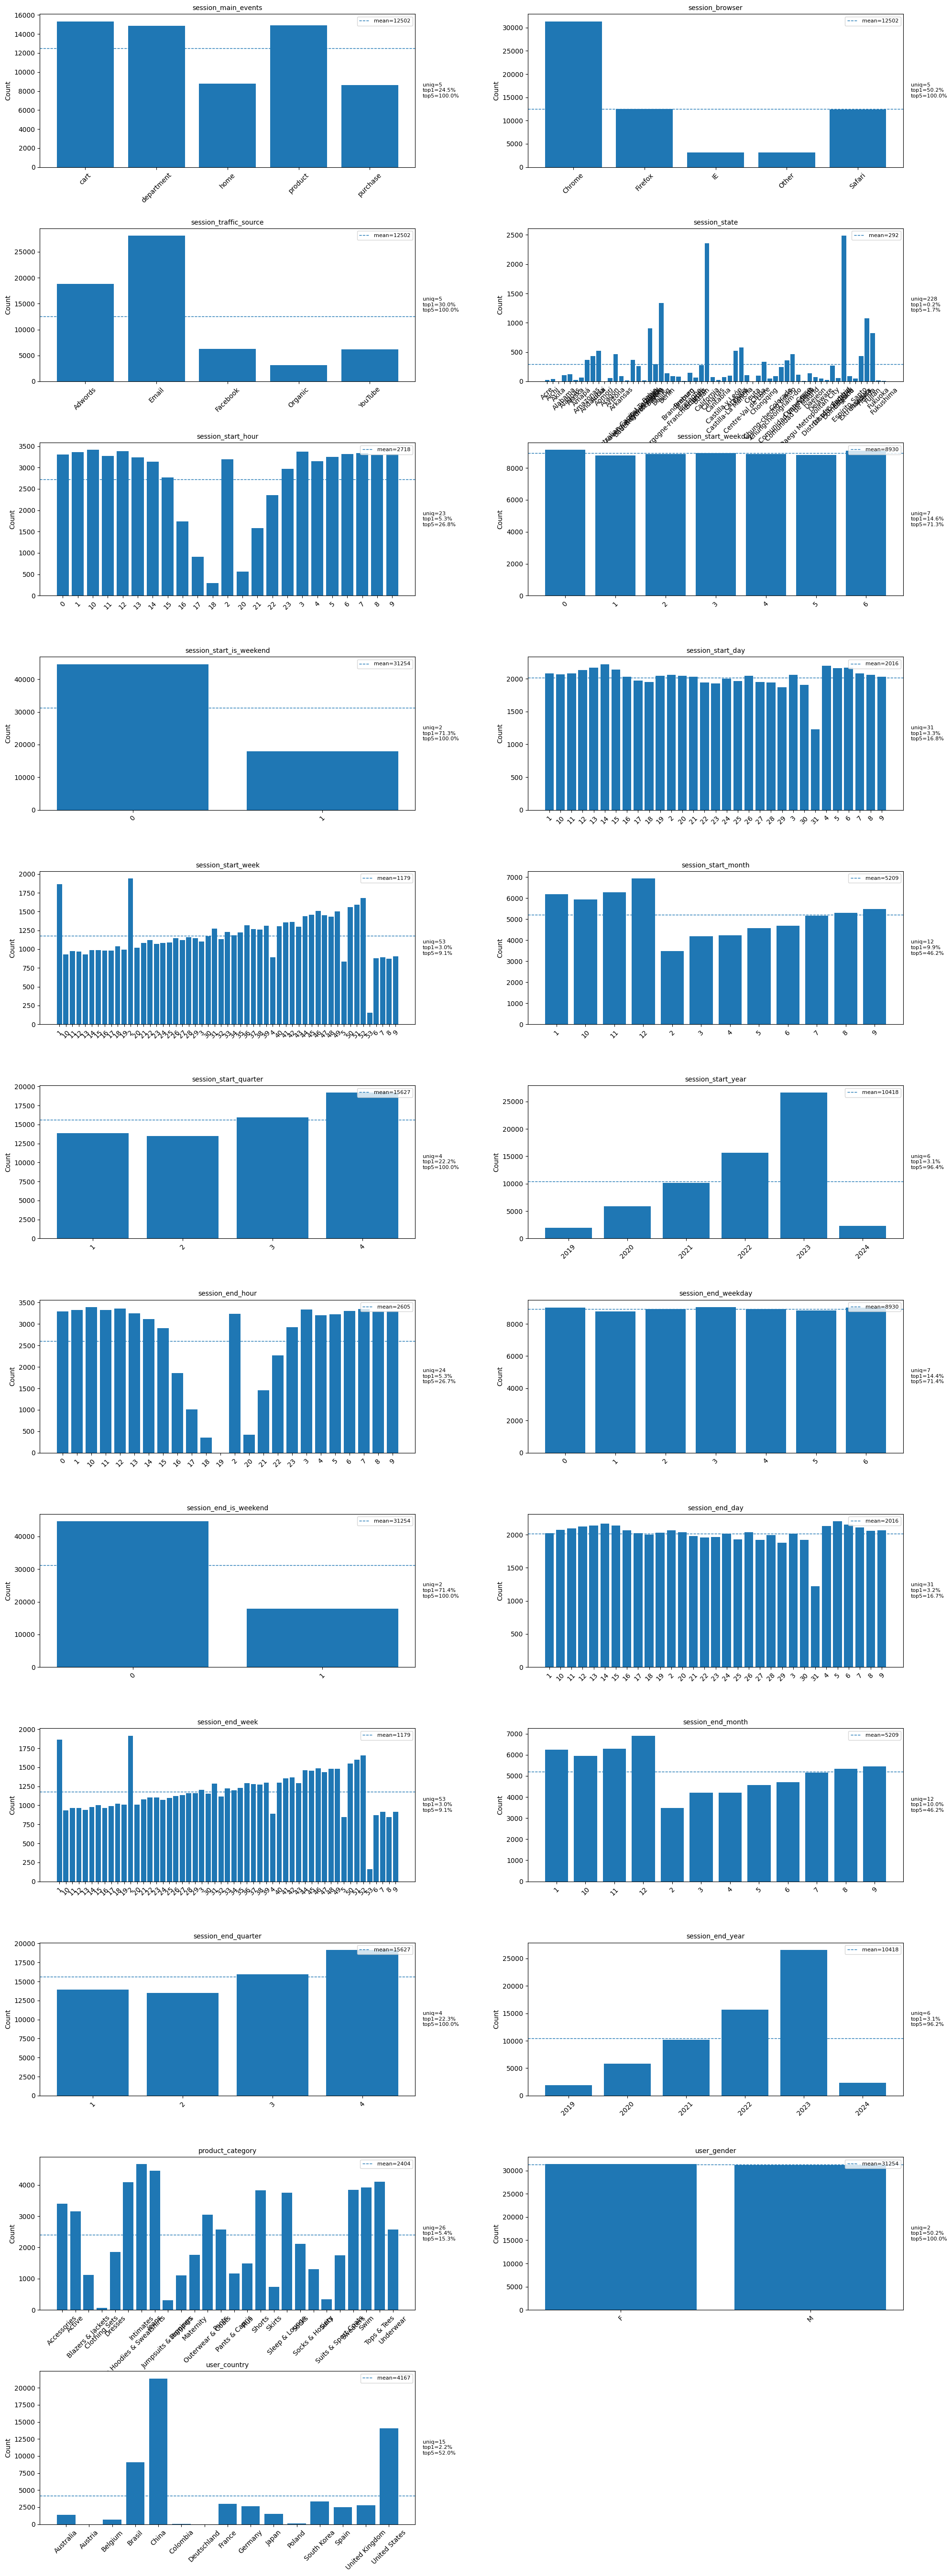

In [24]:
# 컬럼별 개별 top_k 설정
plot_categorical_overview(
    train_df,
    cols=cat_cols,
    per_row=2,
    rotate=45,
    per_ax_size=(10, 4.5),
    na_label="NA",
)

수치형

key_cols, target_col, cat_cols, int_cols, float_cols

In [ ]:
def plot_numeric_combo(df, cols, bins=30, figsize_per_row=(10, 3.5)):
    """
    numeric column 하나당: 
    - 왼쪽: Histogram
    - 오른쪽: Boxplot
    형태로 한 줄(row)에 배치하여 모든 수치형 변수를 시각화한다.
    """

    # 실제로 수치형인 컬럼만 필터링
    numeric_cols = [
        c for c in cols
        if c in df.columns and pd.api.types.is_numeric_dtype(df[c])
    ]

    if not numeric_cols:
        print("수치형 컬럼이 없습니다.")
        return

    n = len(numeric_cols)

    # 전체 Figure 설정
    fig, axes = plt.subplots(
        nrows=n,
        ncols=2,
        figsize=(figsize_per_row[0], figsize_per_row[1] * n)
    )

    # axes가 2차원 배열이 아닌 경우 reshape
    if n == 1:
        axes = np.array([axes])

    for i, col in enumerate(numeric_cols):
        s = df[col].dropna()

        # 1) Histogram
        ax_hist = axes[i, 0]
        ax_hist.hist(s, bins=bins, color="skyblue", edgecolor="black")
        ax_hist.set_title(f"{col} — Histogram")
        ax_hist.set_ylabel("Count")

        # 평균·중앙값 선
        if len(s) > 0:
            ax_hist.axvline(s.mean(), color="red", linestyle="--", linewidth=1,
                            label=f"mean={s.mean():.2f}")
            ax_hist.axvline(s.median(), color="green", linestyle=":", linewidth=1,
                            label=f"median={s.median():.2f}")
            ax_hist.legend(fontsize=8)

        # 2) Boxplot
        ax_box = axes[i, 1]
        ax_box.boxplot(s, vert=False)
        ax_box.set_title(f"{col} — Boxplot")

    plt.tight_layout()
    plt.show()

In [ ]:
plot_numeric_combo(train_df, num_cols)

- 이상치(outlier) 존재
- 정규성 없음(비대칭·long-tail 분포)
- 스케일 차이가 큼

→ MinMaxScaler 사용이 적절할 듯

# 상관 분석

## 수치형 – 수치형
- 우리의 수치형 데이터 특징: 강한 양의 왜도와 극단값이 많아 보임 → 정규성 가정이 깨져 있다.
- 상관계수 확인
    - 스피어만 상관계수(Spearman ρ)
        - 순위(랭크)에 기반하므로 이상치에 덜 민감
        - 피어슨 상관처럼 “선형·정규성·등분산성” 가정에 크게 의존하지 않기 때문에, 지금처럼 왜도가 심하고 outlier가 많은 경우에는 피어슨보다 안정적인 상관 구조를 보여줄 가능성이 높다.
- 시각화
    - 히트맵
        - 변수 간 전체 구조 파악
        - 단조 관계의 방향/강도 파악
        - 이상치의 영향을 크게 받지 않음 
    - 산점도
        - 관계가 단조인지 비단조인지 직접 확인
        - 특정 구간에서만 관계가 달라지는지 점검
        - 클러스터/다중 모드 확인 가능

상관계수 + 히트맵

In [ ]:
# 수치형 변수만 선택
num_df = train_df[num_cols]

# Pearson & Spearman
pearson_corr = num_df.corr(method='pearson')
spearman_corr = num_df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(pearson_corr, annot=False, cmap='coolwarm', ax=axes[0])
axes[0].set_title("Pearson Correlation (Linear)")

sns.heatmap(spearman_corr, annot=False, cmap='coolwarm', ax=axes[1])
axes[1].set_title("Spearman Correlation (Monotonic)")

plt.tight_layout()
plt.show()


산점도

In [ ]:
def plot_lowess_grid(df, cols, frac=0.3):
    pairs = list(combinations(cols, 2))
    n = len(pairs)
    
    n_cols = 3                # 한 줄에 3개
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    axes = axes.flatten()     # 2D → 1D로 평탄화
    
    for idx, (x, y) in enumerate(pairs):
        ax = axes[idx]
        X = df[x].values
        Y = df[y].values
        
        # LOWESS
        lowess = sm.nonparametric.lowess(Y, X, frac=frac)

        # scatter + lowess line
        ax.scatter(X, Y, alpha=0.3, s=15)
        ax.plot(lowess[:, 0], lowess[:, 1], color='red', linewidth=2)

        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.set_title(f"{x} vs {y}")
    
    # 남는 subplot은 지우기
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

In [ ]:
plot_lowess_grid(num_df, num_cols)

In [ ]:
train_df.head()

## 범주형 – 범주형

- 우리의 범주형 데이터 특징: 범주의 비율 차이와 그룹 간 분포 왜곡 여부를 확인해야 함
  → 단순 빈도 차이가 실제 연관 구조인지 검증 필요
- 연관성 확인
  - 교차표(Contingency Table)
    - 범주별 분포 차이 확인
    - 두 변수의 조합 패턴을 직관적으로 파악
  - 카이제곱 검정(Chi-square test)
    - 두 범주형 변수가 독립인지 여부 검정
    - p-value로 유의한 연관성 존재 여부 판단
      - p < 0.05: 두 변수는 독립이 아님
      - p ≥ 0.05: 두 변수는 독립

- 효과 크기 확인
  - Cramér’s V
    - 연관성의 “강도”를 정량적으로 확인
    - 표본 수의 영향을 줄여 실제 영향력 판단 가능
    - 값의 범위: 0 ~ 1
      - 0.00 ~ 0.10	거의 무관 / 매우 약함
      - 0.10 ~ 0.30	약한 연관
      - 0.30 ~ 0.50	중간 연관
      - 0.50 이상	강한 연관

교차표

In [ ]:
def show_crosstabs(df: pd.DataFrame, cat_cols: list):
    """
    cat_cols에 포함된 범주형 변수들의 모든 조합에 대해
    교차표(빈도)만 출력.
    """
    df_cat = df.copy()
    for c in cat_cols:
        df_cat[c] = df_cat[c].astype("string")

    for col1, col2 in combinations(cat_cols, 2):
        print("=" * 80)
        print(f"[{col1} × {col2}] 교차표 (빈도)\n")

        ct = pd.crosstab(df_cat[col1], df_cat[col2])
        print(ct)
        print()  # 줄바꿈


In [ ]:
show_crosstabs(train_df, cat_cols)

In [ ]:
show_crosstabs(train_df, target_col)

카이제곱 + Cramér’s V

In [ ]:
def cramers_v(confusion_matrix: pd.DataFrame) -> float:
    """Cramér's V 계산 함수"""
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / (min(r - 1, k - 1)))

In [ ]:
# --- p-value 해석 ---
def interpret_p_value(p: float) -> str:
    if p >= 0.05:
        return "독립"
    else:
        return "연관성 유의"


# --- Cramér’s V 해석 ---
def interpret_cramers_v(cv: float) -> str:
    if pd.isna(cv):
        return "계산 불가"
    if cv < 0.10:
        return "효과 거의 없음"
    elif cv < 0.30:
        return "약한 연관"
    elif cv < 0.50:
        return "중간 연관"
    else:
        return "강한 연관"

In [ ]:
def summarize_categorical_assoc(df: pd.DataFrame, cat_cols: list) -> pd.DataFrame:
    df_cat = df.copy()
    for c in cat_cols:
        df_cat[c] = df_cat[c].astype("string")

    results = []

    for col1, col2 in combinations(cat_cols, 2):
        ct = pd.crosstab(df_cat[col1], df_cat[col2])
        n = ct.to_numpy().sum()

        # 범주 수 부족 시 스킵
        if ct.shape[0] < 2 or ct.shape[1] < 2:
            results.append({
                "var1": col1,
                "var2": col2,
                "n": n,
                "chi2": np.nan,
                "p_value": np.nan,
                "cramers_v": np.nan,
                "p_value_interp": "계산 불가",
                "cv_interp": "계산 불가"
            })
            continue

        chi2, p, dof, expected = chi2_contingency(ct)
        cv = cramers_v(ct)

        results.append({
            "var1": col1,
            "var2": col2,
            "n": n,
            "chi2": chi2,
            "p_value": p,
            "cramers_v": cv,
            "p_value_interp": interpret_p_value(p),
            "cv_interp": interpret_cramers_v(cv)
        })

    summary_df = pd.DataFrame(results)
    summary_df = summary_df.sort_values("cramers_v", ascending=False, na_position="last")
    summary_df.reset_index(drop=True, inplace=True)

    return summary_df

In [ ]:
assoc_table = summarize_categorical_assoc(train_df, cat_cols+target_col)
display(assoc_table)

## 수치형 – 범주형

- 수치형 분포가 범주별로 유의하게 다른지 확인하는 것이 핵심
- 데이터 특성(강한 왜도·극단값) 고려 시 비모수 검정 기반 접근이 적합
- 분석 기법
  - Kruskal–Wallis 검정
    - 정규성·등분산성 가정을 요구하지 않음
    - 범주형 그룹 간 수치형 분포 차이가 유의한지 판단
  - Boxplot
    - 그룹별 분포·중앙값·범위 차이를 직관적으로 확인
    - 이상치 패턴 파악 가능

Kruskal–Wallis 검정

In [ ]:
def summarize_kw(df, num_cols, cat_cols):
    """
    모든 수치형–범주형 조합에 대해 Kruskal–Wallis p-value를 표로 반환.
    """
    results = []

    for num_col, cat_col in product(num_cols, cat_cols):
        # 범주별 그룹 분할
        groups = [df[df[cat_col] == c][num_col].dropna()
                  for c in df[cat_col].dropna().unique()]

        # 그룹이 2개 이상일 때만 Kruskal 수행
        if len(groups) < 2:
            results.append({
                "numeric": num_col,
                "categorical": cat_col,
                "p_value": None
            })
            continue

        stat, p = kruskal(*groups)

        results.append({
            "numeric": num_col,
            "categorical": cat_col,
            "p_value": p
        })

    summary = pd.DataFrame(results)
    summary["kw_interp"] = summary["p_value"].apply(
        lambda p: "유의함(분포 차이 존재)" if p is not None and p < 0.05 else "비유의(차이 없음)"
    )
    return summary

In [ ]:
kw_table = summarize_kw(train_df, num_cols, cat_cols)
display(kw_table)

In [ ]:
kw_table = summarize_kw(train_df, num_cols, target_col)
display(kw_table)

Boxplot

In [ ]:
def plot_boxplots(df, num_cols, cat_cols):
    pairs = list(product(num_cols, cat_cols))
    n = len(pairs)

    n_cols = 3
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
    axes = axes.flatten()

    for idx, (num_col, cat_col) in enumerate(pairs):
        ax = axes[idx]

        sns.boxplot(data=df, x=cat_col, y=num_col, ax=ax)
        ax.set_title(f"{num_col} by {cat_col}")
        ax.tick_params(axis='x', rotation=30)

    # 남는 subplot 삭제
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [ ]:
plot_boxplots(train_df, num_cols, cat_cols)

In [ ]:
plot_boxplots(train_df, num_cols, target_col)